In [9]:
# 引入本次實驗所需模組
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# 定義一個名為 generate_signal 的函式 
def generate_signal(t, omega=1):
    y = (
        np.sin(omega * t)
        + 0.5 * np.sin(3 * omega * t)
        + 0.2 * np.sin(5 * omega * t)
    )
    return y # 回傳計算出的訊號y

In [11]:
# 取樣設定:在 0 到 T（即 2π)之間產生 N 個等距的數值
N = 1000        # 資料點數
T = 2*np.pi     # 時間範圍(0 到 2π)
# 將結果存入變數 t
t = np.linspace(0, T, N)
# 產生訊號
y = generate_signal(t)

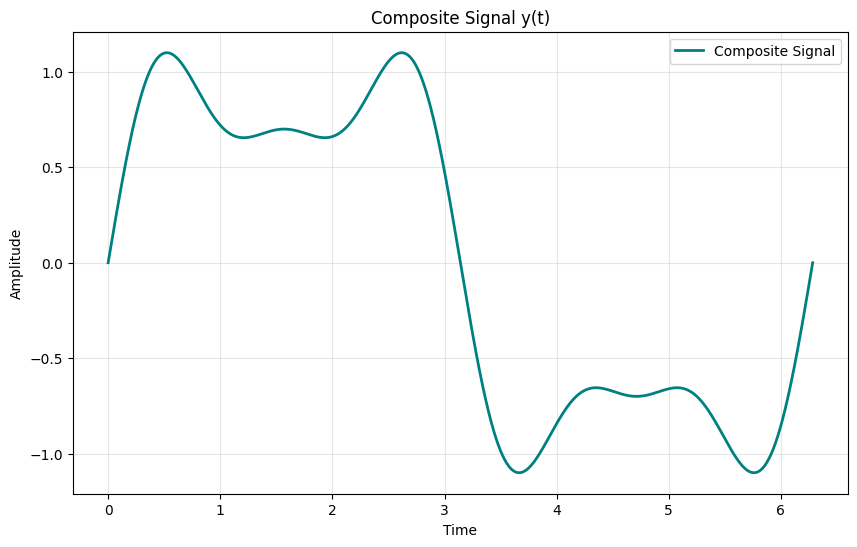

In [12]:
# 先畫ㄍ原始波形
plt.figure(figsize=(10,6))
plt.plot(t, y, color="teal", linewidth=2, label="Composite Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Composite Signal y(t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [13]:
# 檢查：分別畫出三個函式 
t = np.linspace(0, 2*np.pi, 1000)
def generate_each_signal(t, omega=1):
    y1 = np.sin(omega * t)
    y2 = 0.5 * np.sin(3 * omega * t)
    y3 = 0.2 * np.sin(5 * omega * t)

    return y1, y2, y3

y1, y2, y3 = generate_each_signal(t)

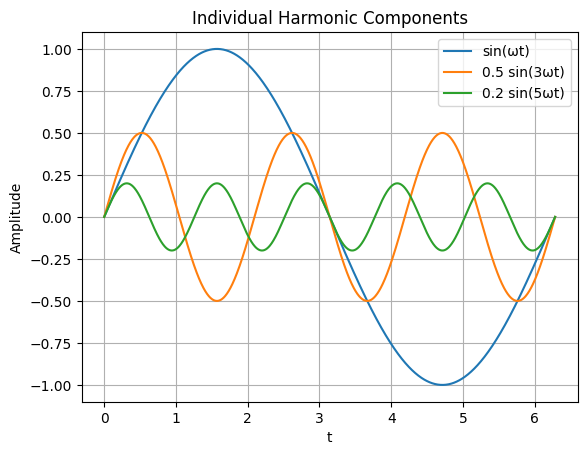

In [14]:
plt.figure()

plt.plot(t, y1, label="sin(ωt)")
plt.plot(t, y2, label="0.5 sin(3ωt)")
plt.plot(t, y3, label="0.2 sin(5ωt)")

plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Individual Harmonic Components")

plt.legend()
plt.grid()

plt.show()

In [15]:
# FFT
Y = np.fft.fft(y) 
freq = np.fft.fftfreq(N, d=(t[1]-t[0]))

# 使用np的fft函式，將訊號從時域（time domain）轉換到頻域（frequency domain）
# 計算頻率軸
# N:訊號樣本數
# d:每個樣本點之間的時間間隔

# 建立布林遮罩 mask，篩選出頻率值大於或等於 0 的部分（留下）
mask = freq >= 0

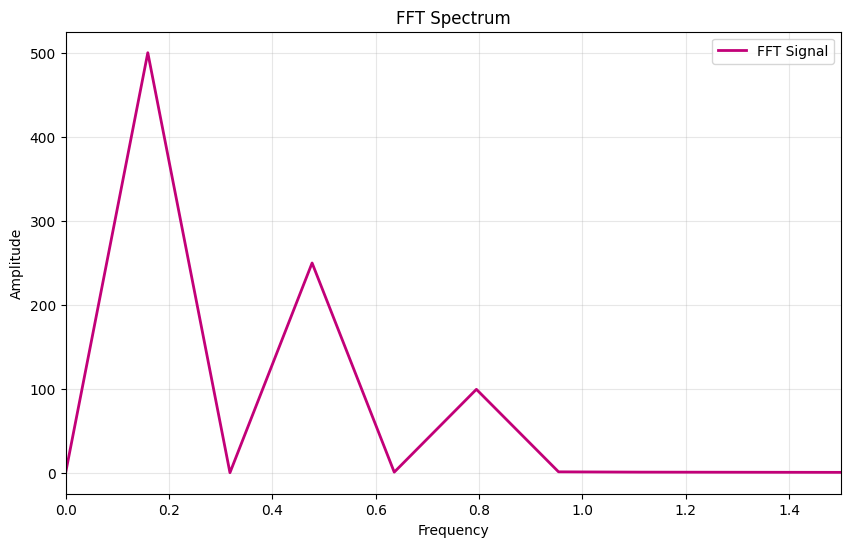

In [16]:
# 繪製 FFT 頻譜圖
plt.figure(figsize=(10,6))
plt.plot(freq[mask], np.abs(Y[mask]), color="#C20078", linewidth=2, label="FFT Signal")
plt.xlim(0, 1.5)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# np.abs(Y[mask])：取 FFT 結果的絕對值（振幅），因為 FFT 結果是複數

思考點 1 (波形vs頻譜)：

當你在示波器上看到一個雜亂無章的波形 (Time Domain)，做完 FFT 後卻發現頻譜圖 (Frequency Domain) 上只有幾根乾淨的「針」(Peaks)。這代表該訊號具有什麼特性？

如果是「白噪音 (White Noise)」，頻譜圖又會長什麼樣子？ 

ANS:

1.代表訊號其實只由少數幾個固定頻率組成，也就是說，這個訊號的頻率成分是離散的，在時域看起來亂是因為不同頻率的波相互干涉，轉換到頻域就沒有這個問題了。

2.白噪音的定義為：訊號在各個頻段上的功率一致，也就是說，白噪音的頻率連續，且沒有任一頻率的振幅是明顯的尖峰，而是隨機起伏，因此頻譜圖應該是在一定頻寬上，連續分布且沒有明顯峰值的雜訊。